<a href="https://colab.research.google.com/github/gduscher/MLSTEM2026/blob/main/Day%204/4PM_hackaton_Agentic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STEM Image-Analysis Agent (smolagents + Gemini)

This notebook provides a sandbox for designing a simple image-analysis agent for **STEM HAADF** data.

The agent is structured using the **smolagents** Python framework. Documentation is available here: https://huggingface.co/docs/smolagents/en/index

As a starting point, several basic image-analysis tools are provided, including load_image, denoise, contrast enhancement, and get_statistics.

The **gemini/gemini-3.1-flash-lite** model is used as the reasoning core and is accessed through the API.

## 1. Install dependencies and upload data

In [2]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "smolagents[litellm]", "scikit-image", "h5py", "gdown", "scifireaders"], check=True)

import h5py
import numpy as np
import json
import matplotlib.pyplot as plt
import SciFiReaders

In [21]:
# ---- HDF5 loader ----
def load_hdf5_to_dict(file_path):
    with h5py.File(file_path, "r") as f:
        return _load_item(f)

def _load_item(obj):
    if isinstance(obj, h5py.Group):
        keys = list(obj.keys())
        if len(keys) == 0 and "value" not in obj.attrs:
            return {}
        if all(k.isdigit() for k in keys):
            return [_load_item(obj[k]) for k in sorted(keys, key=lambda x: int(x))]
        out = {k: _load_item(obj[k]) for k in keys}
        if "value" in obj.attrs and obj.attrs["value"] == "None":
            return None
        return out
    elif isinstance(obj, h5py.Dataset):
        data = obj[()]
        if np.isscalar(data):
            return data
        if isinstance(data, (bytes, np.bytes_)):
            try:    return json.loads(data.decode())
            except: return data.decode()
        if data.dtype.kind == "S":
            try:    return [json.loads(x.decode()) for x in data]
            except: return [x.decode() for x in data]
        return data
    raise ValueError("Unknown HDF5 object type:", obj)

# ---- download (gdown, --fuzzy resolves the share links) ----
!gdown https://drive.google.com/file/d/14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs/view?usp=drive_link --fuzzy
!gdown https://drive.google.com/file/d/1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN/view?usp=drive_link --fuzzy
!gdown https://drive.google.com/file/d/1UP367K9vBi0yEY1cKt9a5p7ZxQu2GjOa/view?usp=sharing --fuzzy

data      = load_hdf5_to_dict("/content/graphene_2.h5")
data1     = SciFiReaders.EMDReader("/content/0174 - 10.5 Mx STEM.emd").read()
data_more = load_hdf5_to_dict("/content/HAADF_21.h5")

im0 = np.asarray(data["Measurement_000"]["Channel_000"]["HAADF"]["HAADF"])[:1000, :1000]
im1 = data1['Channel_004'].compute().mean(0)
im2 = np.asarray(data_more["Measurement_000"]["Channel_000"]["HAADF"]["HAADF"])
IMAGES = [im0, im1, im2]

Downloading...
From: https://drive.google.com/uc?id=14N5Vg7Baqj2OdvgTD1l9oaWWvNvPCpYs
To: /content/graphene_2.h5
100% 17.1M/17.1M [00:00<00:00, 31.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IB2Au4Dh7iNZCeOmj1dmaGB2JOIFAxoN
To: /content/HAADF_21.h5
100% 4.53M/4.53M [00:00<00:00, 154MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1UP367K9vBi0yEY1cKt9a5p7ZxQu2GjOa
From (redirected): https://drive.google.com/uc?id=1UP367K9vBi0yEY1cKt9a5p7ZxQu2GjOa&confirm=t&uuid=2b4552b6-b287-4406-9ad5-6daa17677365
To: /content/0174 - 10.5 Mx STEM.emd
100% 1.01G/1.01G [00:25<00:00, 40.4MB/s]


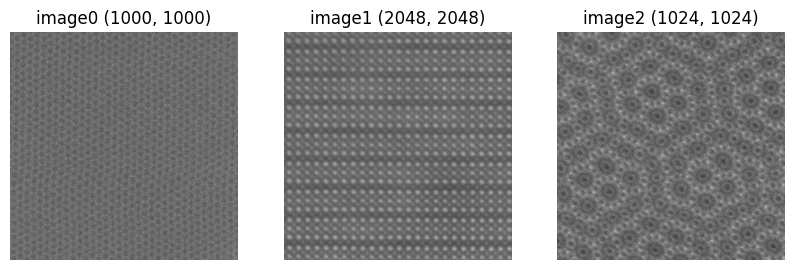

loaded 3 STEM images


In [22]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4))
for i, im in enumerate(IMAGES):
    ax[i].imshow(im, cmap="gray"); ax[i].set_title(f"image{i} {im.shape}"); ax[i].axis("off")
plt.show()
print("loaded", len(IMAGES), "STEM images")

## 3. The image-analysis tools


In [23]:
#@title auxilary


from scipy.ndimage import gaussian_filter, median_filter, convolve
from skimage.restoration import denoise_tv_chambolle, denoise_nl_means
from skimage.exposure import equalize_adapthist, equalize_hist, rescale_intensity
from smolagents import tool

STATE   = {"img": None, "name": None}   # the current working image
RESULTS = {}                            # name -> processed array, retrievable in Python
SHOW    = True                          # display each tool's result inline

def _to_float(a):
    a = np.asarray(a, float)
    lo, hi = np.percentile(a, [0.5, 99.5])
    if hi <= lo: hi = lo + 1.0
    return np.clip((a - lo) / (hi - lo), 0, 1)

# Immerker (1996) noise-sigma estimate -> dependency-free SNR
_M = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], float)
def _noise_sigma(f):
    H, W = f.shape
    return float(np.sqrt(np.pi / 2) * np.sum(np.abs(convolve(f, _M))) / (6 * (W - 2) * (H - 2)))
def _snr_db(f):
    return float(20 * np.log10((f.std() + 1e-9) / (_noise_sigma(f) + 1e-9)))

def _show(img, title):
    if not SHOW: return
    plt.figure(figsize=(4.5, 4.5)); plt.imshow(img, cmap="gray")
    plt.title(title); plt.axis("off"); plt.show()

def _store(name, arr, title):
    "Make arr the current image, keep a named copy in RESULTS, and display it."
    STATE["img"], STATE["name"] = arr, name
    RESULTS[name] = arr
    _show(arr, title)
    return name

def get_image(name=None):
    "Return a processed array by name (default: the current image); see list_results()."
    return STATE["img"] if name is None else RESULTS.get(name)

def list_results():
    "Names of every array produced so far, oldest first."
    return list(RESULTS)

Below are examples of the different tools available to the agent. The docstrings are used to provide context and instructions for how the agent should use each tool.

In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt

from smolagents import tool
from scipy.ndimage import gaussian_filter, median_filter
from skimage.restoration import denoise_tv_chambolle, denoise_nl_means
from skimage.exposure import equalize_adapthist, equalize_hist, rescale_intensity


# -----------------------------
# Small helpers for unified tools
# -----------------------------

def _current_image():
    """Return the current image or None."""
    return STATE.get("img", None)


def _current_name():
    """Return current image name."""
    return STATE.get("name", "current_image")


def _validate_current_image():
    """Return (ok, image_or_message)."""
    f = _current_image()
    if f is None:
        return False, "No image loaded. Call load_image(index) first."
    return True, np.asarray(f, dtype=float)


def _safe_float(x):
    """Convert NumPy scalar to plain Python float."""
    return float(np.asarray(x))


def _format_shape(arr):
    """Format image shape as text."""
    return f"{arr.shape[0]} x {arr.shape[1]} px"


# -----------------------------
# Image loading / state tools
# -----------------------------

@tool
def list_images() -> str:
    """
    List available STEM images with their index and pixel shape.

    Returns:
        Text list of available images.
    """
    if len(IMAGES) == 0:
        return "No images are available."

    lines = ["Available STEM images:"]
    for i, im in enumerate(IMAGES):
        arr = np.asarray(im)
        lines.append(f"  index {i}: shape {arr.shape}")

    return "\n".join(lines)


@tool
def load_image(index: int) -> str:
    """
    Load an available STEM image and make it the current image.

    Args:
        index: Image index from 0 to len(IMAGES)-1.

    Returns:
        Status message with image shape, noise estimate, and SNR.
    """
    if len(IMAGES) == 0:
        return "No images are available."

    if not isinstance(index, int):
        return "Invalid index. The index must be an integer."

    if not (0 <= index < len(IMAGES)):
        return f"Invalid index {index}. Available image indices are 0..{len(IMAGES) - 1}."

    f = _to_float(IMAGES[index])
    name = _store(f"image{index}", f, f"image{index} loaded")

    return (
        f"Loaded image {index} as current image '{name}'. "
        f"Shape: {_format_shape(f)}. "
        f"SNR: {_snr_db(f):.2f} dB."
    )


# -----------------------------
# Analysis tools
# -----------------------------

@tool
def get_image_stats() -> str:
    """
    Calculate basic statistics for the current STEM image.

    Returns:
        Text summary with shape, intensity statistics, noise estimate, and SNR.
    """
    ok, result = _validate_current_image()
    if not ok:
        return result

    f = result

    return (
        f"Statistics for current image '{_current_name()}': "
        f"shape {_format_shape(f)}, "
        f"mean {_safe_float(np.nanmean(f)):.4f}, "
        f"std {_safe_float(np.nanstd(f)):.4f}, "
        f"min {_safe_float(np.nanmin(f)):.4f}, "
        f"max {_safe_float(np.nanmax(f)):.4f}, "
        f"median {_safe_float(np.nanmedian(f)):.4f}, "
        f"p01 {_safe_float(np.nanpercentile(f, 1)):.4f}, "
        f"p99 {_safe_float(np.nanpercentile(f, 99)):.4f}, "
        f"SNR {_snr_db(f):.2f} dB."
    )


@tool
def make_fft(null_dc: bool = True, dc_radius: int = 3) -> str:
    """
    Calculate the 2D FFT log-magnitude image for the current STEM image.

    Args:
        null_dc: Whether to suppress the central DC peak before estimating the dominant period.
        dc_radius: Radius in pixels around the FFT center to suppress when null_dc is true.

    Returns:
        Status message with estimated dominant period and stored FFT result name.
    """
    ok, result = _validate_current_image()
    if not ok:
        return result

    f = result
    H, W = f.shape

    # Remove mean before FFT to reduce the DC component.
    centered = f - np.nanmean(f)

    F = np.fft.fftshift(np.abs(np.fft.fft2(centered)))
    logF = np.log1p(F)

    cy, cx = H // 2, W // 2
    F_for_peak = F.copy()

    if null_dc:
        r = max(1, int(dc_radius))
        y0, y1 = max(0, cy - r), min(H, cy + r + 1)
        x0, x1 = max(0, cx - r), min(W, cx + r + 1)
        F_for_peak[y0:y1, x0:x1] = 0

    py, px = np.unravel_index(np.argmax(F_for_peak), F_for_peak.shape)
    freq_px = np.hypot(py - cy, px - cx)
    dominant_period_px = min(H, W) / freq_px if freq_px > 0 else float("inf")

    result_name = f"{_current_name()}|fft_log"
    RESULTS[result_name] = logF

    if SHOW:
        fig, ax = plt.subplots(1, 2, figsize=(8, 4))
        ax[0].imshow(f, cmap="gray")
        ax[0].set_title("current image")
        ax[0].axis("off")

        ax[1].imshow(logF, cmap="magma")
        ax[1].set_title("log |FFT|")
        ax[1].axis("off")

        plt.tight_layout()
        plt.show()

    return (
        f"FFT calculated for current image '{_current_name()}'. "
        f"FFT log-magnitude stored in RESULTS as '{result_name}'. "
        f"Dominant FFT peak at pixel offset ({py - cy}, {px - cx}). "
        f"Estimated dominant period: {dominant_period_px:.2f} px."
    )


# -----------------------------
# Image processing tools
# -----------------------------

@tool
def denoise_image(method: str = "tv", strength: float = 1.0) -> str:
    """
    Denoise the current STEM image and make the denoised result the new current image.

    Args:
        method: Denoising method. Use one of: gaussian, median, tv, nlmeans.
        strength: Denoising strength. Larger values produce smoother images. Typical range is 0.5 to 3.

    Returns:
        Status message with before/after noise estimate and SNR.
    """
    ok, result = _validate_current_image()
    if not ok:
        return result

    f = result
    method = method.lower().strip()

    try:
        strength = float(strength)
    except Exception:
        return "Invalid strength. Strength must be a number."

    strength = max(0.0, strength)

    noise_before = _noise_sigma(f)

    if method == "gaussian":
        sigma = max(0.3, strength)
        d = gaussian_filter(f, sigma=sigma)

    elif method == "median":
        size = max(2, int(round(strength)) + 1)
        d = median_filter(f, size=size)

    elif method == "tv":
        weight = 0.05 * max(0.1, strength)
        d = denoise_tv_chambolle(f, weight=weight)

    elif method == "nlmeans":
        sigma_est = max(1e-6, _noise_sigma(f))
        h = max(1e-3, strength * sigma_est)
        d = denoise_nl_means(
            f,
            h=h,
            fast_mode=True,
            patch_size=5,
            patch_distance=6,
        )

    else:
        return "Unknown denoising method. Use one of: gaussian, median, tv, nlmeans."

    name = _store(
        f"{_current_name()}+denoise_{method}",
        d,
        f"denoised using {method}, strength={strength}",
    )

    noise_after = _noise_sigma(d)

    return (
        f"Denoising complete. "
        f"Method: {method}. Strength: {strength}. "
        f"Noise sigma: {noise_before:.4f} -> {noise_after:.4f}. "
        f"SNR after denoising: {_snr_db(d):.2f} dB. "
        f"Result stored as current image '{name}'."
    )


@tool
def enhance_contrast(method: str = "clahe", clip_limit: float = 0.02) -> str:
    """
    Enhance contrast of the current STEM image and make the enhanced result the new current image.

    Args:
        method: Contrast method. Use one of: clahe, equalize, stretch.
        clip_limit: CLAHE clip limit. Typical range is 0.01 to 0.05. Ignored for equalize and stretch.

    Returns:
        Status message with before/after contrast estimate.
    """
    ok, result = _validate_current_image()
    if not ok:
        return result

    f = result
    method = method.lower().strip()

    try:
        clip_limit = float(clip_limit)
    except Exception:
        return "Invalid clip_limit. clip_limit must be a number."

    std_before = np.nanstd(f)

    # Normalize to [0, 1] for stable contrast operations.
    f01 = rescale_intensity(f, in_range="image", out_range=(0, 1))

    if method == "clahe":
        clip_limit = float(np.clip(clip_limit, 0.001, 0.2))
        d = equalize_adapthist(f01, clip_limit=clip_limit)

    elif method == "equalize":
        d = equalize_hist(f01)

    elif method == "stretch":
        p2, p98 = np.nanpercentile(f, [2, 98])
        if p98 <= p2:
            return "Cannot apply contrast stretching because image percentiles are degenerate."
        d = rescale_intensity(f, in_range=(p2, p98), out_range=(0, 1))

    else:
        return "Unknown contrast method. Use one of: clahe, equalize, stretch."

    name = _store(
        f"{_current_name()}+contrast_{method}",
        d,
        f"contrast enhanced using {method}",
    )

    std_after = np.nanstd(d)

    return (
        f"Contrast enhancement complete. "
        f"Method: {method}. "
        f"Intensity std: {std_before:.4f} -> {std_after:.4f}. "
        f"Result stored as current image '{name}'."
    )


# -----------------------------
# Tool list
# -----------------------------

STEM_IMAGE_TOOLS = [
    list_images,
    load_image,
    get_image_stats,
    make_fft,
    denoise_image,
    enhance_contrast,
]

print("tools ready:", [t.name for t in STEM_IMAGE_TOOLS])

tools ready: ['list_images', 'load_image', 'get_image_stats', 'make_fft', 'denoise_image', 'enhance_contrast']


## 4.LLM Model — Gemini

Get a free key at **https://aistudio.google.com/apikey**, then add it as a Colab **Secret**: key icon in the left sidebar -> **Add new secret** -> name `GEMINI_API_KEY`, paste the value, enable **Notebook access**.

In [25]:
import os
key = os.environ.get("GEMINI_API_KEY")
if not key:
    try:
        from google.colab import userdata
        key = userdata.get("GEMINI_API_KEY")
    except Exception:
        key = None
assert key, ("No GEMINI_API_KEY found. Get a free key at https://aistudio.google.com/apikey, "
             "then add it as a Colab Secret named GEMINI_API_KEY (key icon -> enable Notebook access).")
os.environ["GEMINI_API_KEY"] = key

from smolagents import LiteLLMModel
# temperature=0 -> deterministic tool calls; requests_per_minute keeps us under the free tier.
model = LiteLLMModel(model_id="gemini/gemini-3.1-flash-lite",
                     api_key=key,
                     requests_per_minute=12,
                     verbosity_level=0,)

## 5. Build the agent

A `ToolCallingAgent`. Tools share the current image, so the agent can chain steps. `ask("...")` sends one request.

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ List the available images, then load image 0 and report its SNR.                                                │
│                                                                                                                 │
╰─ LiteLLMModel - gemini/gemini-3.1-flash-lite ───────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'list_images' with arguments: {}                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: Available STEM images:
  index 0: shape (1000, 1000)
  index 1: shape (2048, 2048)
  index 2: shape (1024, 1024)

[Step 1: Duration 0.95 seconds| Input tokens: 2,012 | Output tokens: 10]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'load_image' with arguments: {'index': 0}                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

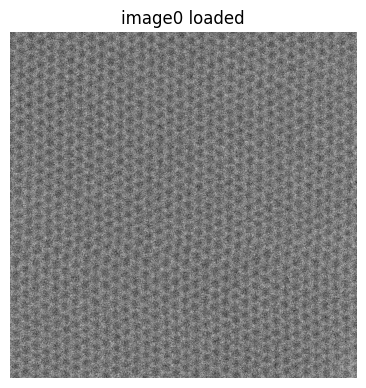

Observations: Loaded image 0 as current image 'image0'. Shape: 1000 x 1000 px. SNR: 0.31 dB.

[Step 2: Duration 5.38 seconds| Input tokens: 4,177 | Output tokens: 24]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'final_answer' with arguments: {'answer': "The available images are: index 0 (1000x1000), index 1 │
│ (2048x2048), and index 2 (1024x1024). Image 0 has been loaded and its SNR is 0.31 dB.\n\ntools_used:            │
│ ['list_images', 'load_image']\nmeasured_values: {'image_0_snr': '0.31 dB'}\ninterpretation: The signal-to-noise │
│ ratio of the loaded image (index 0) is 0.31 dB, which indicates a very noisy image."}                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: The available images are: index 0 (1000x1000), index 1 (2048x2048), and index 2 (1024x1024). Image 0 
has been loaded and its SNR is 0.31 dB.

tools_used: |'list_images', 'load_image']
measured_values: {'image_0_snr': '0.31 dB'}
interpretation: The signal-to-noise ratio of the loaded image (index 0) is 0.31 dB, which indicates a very noisy 
image.

Final answer: The available images are: index 0 (1000x1000), index 1 (2048x2048), and index 2 (1024x1024). Image 0 
has been loaded and its SNR is 0.31 dB.

tools_used: ['list_images', 'load_image']
measured_values: {'image_0_snr': '0.31 dB'}
interpretation: The signal-to-noise ratio of the loaded image (index 0) is 0.31 dB, which indicates a very noisy 
image.

[Step 3: Duration 5.06 seconds| Input tokens: 6,473 | Output tokens: 173]

The available images are: index 0 (1000x1000), index 1 (2048x2048), and index 2 (1024x1024). Image 0 has been loaded and its SNR is 0.31 dB.

tools_used: ['list_images', 'load_image']
measured_values: {'image_0_snr': '0.31 dB'}
interpretation: The signal-to-noise ratio of the loaded image (index 0) is 0.31 dB, which indicates a very noisy image.


In [40]:
from smolagents import ToolCallingAgent

TOOLS = STEM_IMAGE_TOOLS #define

INSTRUCTIONS = (
    "You are an assistant for analysing STEM images. "
    "Use ONLY the provided tools and choose the fewest calls that satisfy the request. "
    "Base every number on an actual tool result. Do not invent values. "
    "At the end, return a short structured text summary with exactly three sections: "
    "tools_used: a Python-style list of tool names that were called; "
    "measured_values: a JSON-like dictionary containing only values returned by tools; "
    "interpretation: one or two short sentences based only on the measured values."
)

agent = ToolCallingAgent(tools=TOOLS,
                         model=model,
                         add_base_tools=False,
                         max_steps=6,
                         verbosity_level=1,
                         instructions=INSTRUCTIONS)

def ask(query):
    "Send one natural-language image-analysis request to the agent."
    return agent.run(query)

print(ask("List the available images, then load image 0 and report its SNR."))

## 6. Example commands
Run one at a time on the free tier. Each tool also shows its output image as it runs.

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Get a basic statistic for the image 0                                                                           │
│                                                                                                                 │
╰─ LiteLLMModel - gemini/gemini-3.1-flash-lite ───────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'load_image' with arguments: {'index': 0}                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

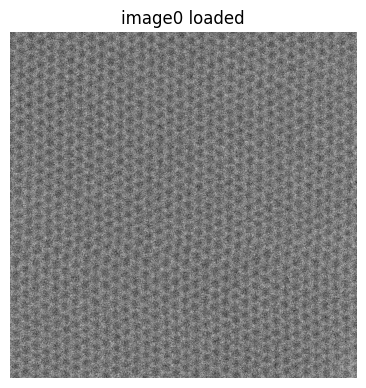

Observations: Loaded image 0 as current image 'image0'. Shape: 1000 x 1000 px. SNR: 0.31 dB.

[Step 1: Duration 1.41 seconds| Input tokens: 2,006 | Output tokens: 14]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'get_image_stats' with arguments: {}                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: Statistics for current image 'image0': shape 1000 x 1000 px, mean 0.4689, std 0.1930, min 0.0000, max
1.0000, median 0.4636, p01 0.0410, p99 0.9442, SNR 0.31 dB.

...

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'final_answer' with arguments: {'answer': "The basic statistics for image 0 are: shape 1000 x     │
│ 1000 px, mean 0.4689, std 0.1930, min 0.0000, max 1.0000, median 0.4636, p01 0.0410, p99 0.9442, and SNR 0.31   │
│ dB.\n\ntools_used: ['load_image', 'get_image_stats']\nmeasured_values: {'shape': '1000 x 1000 px', 'mean':      │
│ 0.4689, 'std': 0.193, 'min': 0.0, 'max': 1.0, 'median': 0.4636, 'p01': 0.041, 'p99': 0.9442, 'SNR': '0.31       │
│ dB'}\ninterpretation: The image has a mean intensity of 0.4689 with a standard deviation of 0.1930, spanning    │
│ the full range of 0 to 1, and possesses a low signal-to-noise ratio of 0.31 dB."}                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: The basic statistics for image 0 are: shape 1000 x 1000 px, mean 0.4689, std 0.1930, min 0.0000, max 
1.0000, median 0.4636, p01 0.0410, p99 0.9442, and SNR 0.31 dB.

tools_used: |'load_image', 'get_image_stats']
measured_values: {'shape': '1000 x 1000 px', 'mean': 0.4689, 'std': 0.193, 'min': 0.0, 'max': 1.0, 'median': 
0.4636, 'p01': 0.041, 'p99': 0.9442, 'SNR': '0.31 dB'}
interpretation: The image has a mean intensity of 0.4689 with a standard deviation of 0.1930, spanning the full 
range of 0 to 1, and possesses a low signal-to-noise ratio of 0.31 dB.

Final answer: The basic statistics for image 0 are: shape 1000 x 1000 px, mean 0.4689, std 0.1930, min 0.0000, max 
1.0000, median 0.4636, p01 0.0410, p99 0.9442, and SNR 0.31 dB.

tools_used: ['load_image', 'get_image_stats']
measured_values: {'shape': '1000 x 1000 px', 'mean': 0.4689, 'std': 0.193, 'min': 0.0, 'max': 1.0, 'median': 
0.4636, 'p01': 0.041, 'p99': 0.9442, 'SNR': '0.31 dB'}
interpretation: The image has a mean intensity of 0.4689 with a standard deviation of 0.1930, spanning the full 
range of 0 to 1, and possesses a low signal-to-noise ratio of 0.31 dB.

[Step 3: Duration 5.62 seconds| Input tokens: 6,487 | Output tokens: 320]

The basic statistics for image 0 are: shape 1000 x 1000 px, mean 0.4689, std 0.1930, min 0.0000, max 1.0000, median 0.4636, p01 0.0410, p99 0.9442, and SNR 0.31 dB.

tools_used: ['load_image', 'get_image_stats']
measured_values: {'shape': '1000 x 1000 px', 'mean': 0.4689, 'std': 0.193, 'min': 0.0, 'max': 1.0, 'median': 0.4636, 'p01': 0.041, 'p99': 0.9442, 'SNR': '0.31 dB'}
interpretation: The image has a mean intensity of 0.4689 with a standard deviation of 0.1930, spanning the full range of 0 to 1, and possesses a low signal-to-noise ratio of 0.31 dB.


In [42]:
print(ask("Get a basic statistic for the image 0"))

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ How many atoms are on image 0?                                                                                  │
│                                                                                                                 │
╰─ LiteLLMModel - gemini/gemini-3.1-flash-lite ───────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'load_image' with arguments: {'index': 0}                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

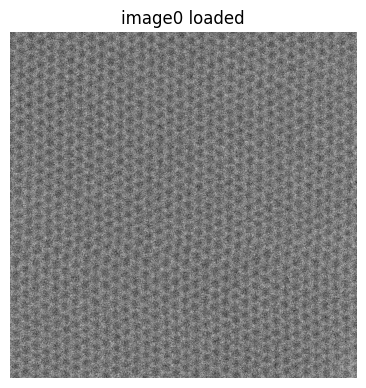

Observations: Loaded image 0 as current image 'image0'. Shape: 1000 x 1000 px. SNR: 0.31 dB.

[Step 1: Duration 1.14 seconds| Input tokens: 2,006 | Output tokens: 14]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'make_fft' with arguments: {'null_dc': True}                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

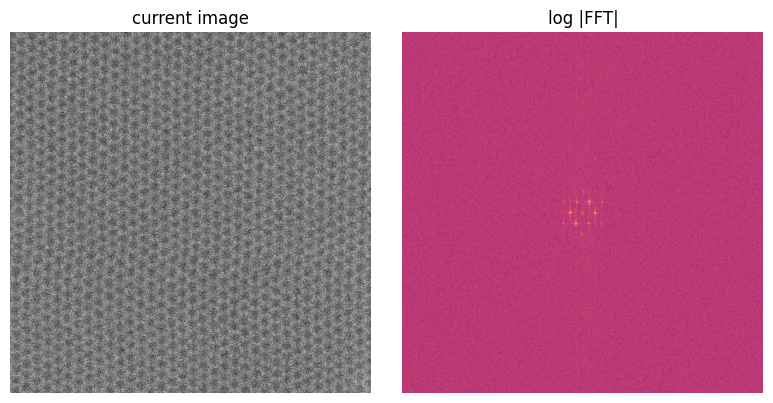

Observations: FFT calculated for current image 'image0'. FFT log-magnitude stored in RESULTS as 'image0|fft_log'. 
Dominant FFT peak at pixel offset (-30, -16). Estimated dominant period: 29.41 px.

[Step 2: Duration 5.26 seconds| Input tokens: 4,147 | Output tokens: 30]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'final_answer' with arguments: {'answer': 'The image has a dominant periodicity of approximately  │
│ 29.41 pixels. Without further information or object detection capabilities, it is not possible to directly      │
│ count individual atoms in the image, but the periodicity suggests a regular lattice structure.'}                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: The image has a dominant periodicity of approximately 29.41 pixels. Without further information or 
object detection capabilities, it is not possible to directly count individual atoms in the image, but the 
periodicity suggests a regular lattice structure.

Final answer: The image has a dominant periodicity of approximately 29.41 pixels. Without further information or 
object detection capabilities, it is not possible to directly count individual atoms in the image, but the 
periodicity suggests a regular lattice structure.

[Step 3: Duration 4.41 seconds| Input tokens: 6,444 | Output tokens: 91]

The image has a dominant periodicity of approximately 29.41 pixels. Without further information or object detection capabilities, it is not possible to directly count individual atoms in the image, but the periodicity suggests a regular lattice structure.


In [43]:
print(ask("How many atoms are on image 0?"))

# 7. Inspect the current image yourself

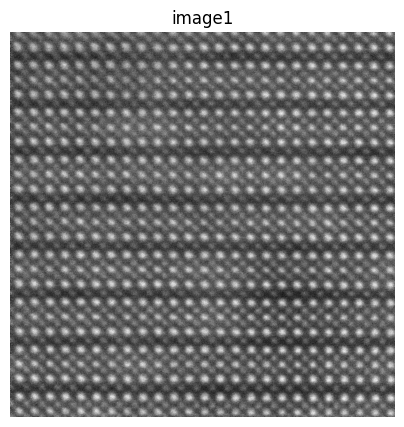

stored results: ['image0', 'image1', 'image1|fft_log']
current array: ((2048, 2048), dtype('float64'))


In [31]:
def show_current():
    f = STATE["img"]
    if f is None: print("no current image - run ask('load image 0') first"); return
    plt.figure(figsize=(5, 5)); plt.imshow(f, cmap="gray")
    plt.title(STATE["name"]); plt.axis("off"); plt.show()

def reset(index=0):
    "Reload a clean source image as the current image."
    _store(f"image{index}", _to_float(IMAGES[index]), f"image{index} (reset)")
    print("current image reset to image%d" % index)

show_current()
print("stored results:", list_results())
arr = get_image()                      # the latest cleaned/changed array (NumPy)
print("current array:", None if arr is None else (arr.shape, arr.dtype))

### Equip an agent with tools to:

            a) detect atomic columns,

            b) classify column types,